In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display general information about the DataFrame
print("\nGeneral information about the dataset:")
df.info()

# Display descriptive statistics of numerical columns
print("\nDescriptive statistics of numerical columns:")
display(df.describe())

# Check for missing values
print("\nMissing values count per column:")
display(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

First 5 rows of the dataset:


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1



General information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000



Missing values count per column:


,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0



Number of duplicate rows: 0


In [2]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)
print(f"Number of rows after dropping duplicates: {len(df)}")

# Impute missing values
# For numerical columns, use the median
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

# For categorical columns, use the mode or a placeholder like 'Unknown'
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

print("\nMissing values after imputation:")
display(df.isnull().sum())

Number of rows after dropping duplicates: 7500
Filled missing values in 'addiction_level' with mode: Moderate

Missing values after imputation:


/tmp/ipykernel_4362/3858700880.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


ValueError: num must be an integer with 1 <= num <= 18, not 19

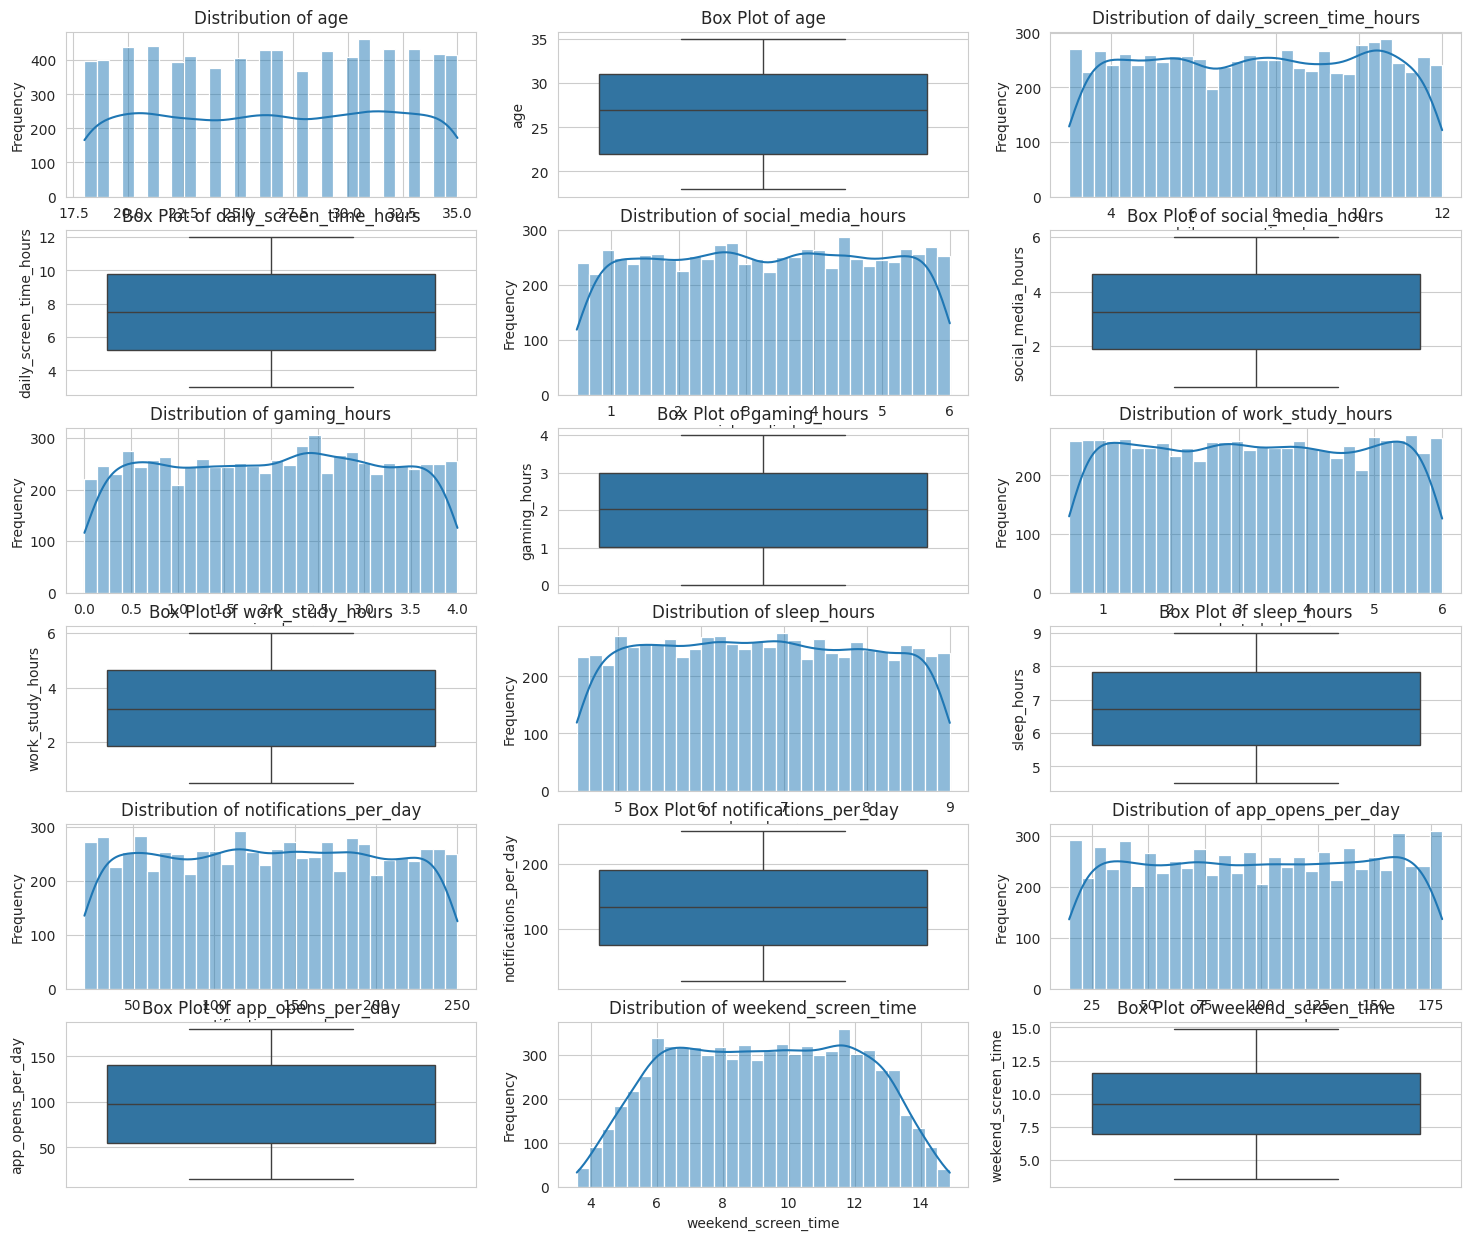

In [3]:
# Set style for plots
sns.set_style("whitegrid")

# Univariate Analysis for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    if col != 'User_ID': # Assuming User_ID is just an identifier
        plt.subplot(len(numerical_cols) // 2 + 1, 3, 2*i + 1) # Histogram
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

        plt.subplot(len(numerical_cols) // 2 + 1, 3, 2*i + 2) # Box plot
        sns.boxplot(y=df[col])
        plt.title(f'Box Plot of {col}')
        plt.ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
# Univariate Analysis for Categorical Columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

plt.figure(figsize=(18, 5 * len(categorical_cols)))
for i, col in enumerate(categorical_cols):
    plt.subplot(len(categorical_cols) // 2 + 1, 2, i + 1)
    sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
    plt.title(f'Count Plot of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4362/1077343749.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_4362/1077343749.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_4362/1077343749.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_4362/1077343749.py:7: FutureWarning: 

Passing `palette` without assignin

In [ ]:
outlier_cols = ['Daily_Usage_Time_minutes', 'Social_Media_Usage_minutes', 'Gaming_Usage_minutes', 'Productivity_Usage_minutes'] # Select relevant numerical columns for outlier detection

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\nOutliers in '{col}' (using IQR method): {len(outliers)} samples")
    if not outliers.empty:
        display(outliers[['User_ID', col]].head()) # Display first few outliers with User_ID

In [ ]:
# Correlation Matrix for Numerical Variables
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
# Numerical vs. Numerical: Scatter plots
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Daily_Usage_Time_minutes', y='Social_Media_Usage_minutes', data=df, hue='Addiction_Level')
plt.title('Daily Usage vs. Social Media Usage by Addiction Level')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Gaming_Usage_minutes', y='Productivity_Usage_minutes', data=df, hue='Addiction_Level')
plt.title('Gaming Usage vs. Productivity Usage by Addiction Level')

plt.tight_layout()
plt.show()

In [ ]:
# Numerical vs. Categorical: Box plots
# Example: Daily Usage Time by Gender
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Gender', y='Daily_Usage_Time_minutes', data=df, palette='pastel')
plt.title('Daily Usage Time by Gender')

# Example: Social Media Usage by Addiction Level
plt.subplot(1, 2, 2)
sns.boxplot(x='Addiction_Level', y='Social_Media_Usage_minutes', data=df, palette='coolwarm')
plt.title('Social Media Usage by Addiction Level')

plt.tight_layout()
plt.show()

# Example: Daily Usage Time by Education Level
plt.figure(figsize=(10, 6))
sns.violinplot(x='Education_Level', y='Daily_Usage_Time_minutes', data=df, palette='muted', order=df['Education_Level'].value_counts().index)
plt.title('Daily Usage Time by Education Level')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Categorical vs. Categorical: Stacked Bar Charts or Count plots with Hue
# Example: Gender distribution by Addiction Level
plt.figure(figsize=(10, 7))
sns.countplot(x='Addiction_Level', hue='Gender', data=df, palette='deep')
plt.title('Addiction Level by Gender')
plt.show()

# Example: Education Level by Addiction Level
plt.figure(figsize=(12, 7))
sns.countplot(x='Education_Level', hue='Addiction_Level', data=df, palette='viridis', order=df['Education_Level'].value_counts().index)
plt.title('Addiction Level by Education Level')
plt.xticks(rotation=45)
plt.show()